In [1001]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [1002]:
df_da_us = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

In [1003]:
# Drop rows where salary_year_avg is missing (optional, if needed)
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

# Explode the job_skills column
df_da_us_exploded = df_da_us.explode('job_skills')

# Preview
df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [1004]:
df_da_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False) 
df_da_skills = df_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
da_job_count = len(df_da_us)
df_da_skills['skill_percent'] = (df_da_skills['skill_count'] / da_job_count) * 100

skill_percent = 5
df_da_skills_high_demand = df_da_skills[df_da_skills['skill_percent'] > skill_percent]
df_da_skills_high_demand



,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


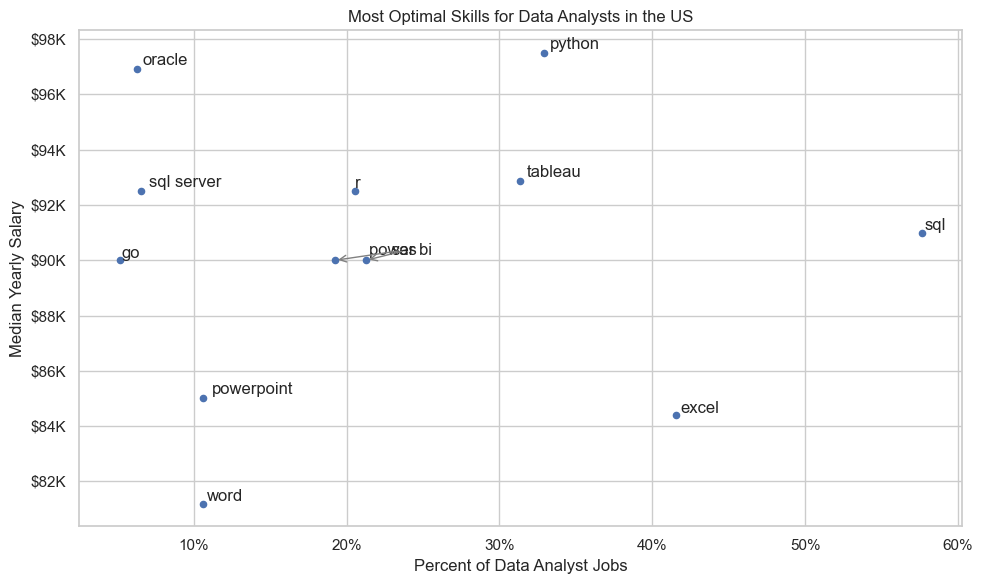

In [1005]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

# Scatter plot
df_da_skills_high_demand.plot(
    kind='scatter', x='skill_percent', y='median_salary', figsize=(10,6)
)

# Add text labels
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(
        plt.text(
            df_da_skills_high_demand['skill_percent'].iloc[i],
            df_da_skills_high_demand['median_salary'].iloc[i],
            txt
        )
    )

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'), expand_points=(1.2,1.2))

# Labels and title
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

In [1006]:
import ast
import pandas as pd

# Copy the 'job_type_skills' column
df_technology = df['job_type_skills'].copy()

# Remove duplicates
df_technology = df_technology.drop_duplicates()

# Remove NaN values
df_technology = df_technology.dropna()

# Initialize the dictionary to combine all dictionaries
technology_dict = {}

# Iterate over each row
for row in df_technology:
    # Convert string representation of dictionary to an actual dictionary
    row_dict = ast.literal_eval(row)
    
    # Merge row_dict into technology_dict
    for key, value in row_dict.items():
        if key in technology_dict:
            # If key already exists, extend the existing list
            technology_dict[key] += value
        else:
            # If key does not exist, create a new entry
            technology_dict[key] = value

# Remove duplicates in the lists
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

# Show the final dictionary
technology_dict

{'analyst_tools': ['power bi',
  'nuix',
  'powerbi',
  'microstrategy',
  'ms access',
  'sap',
  'spreadsheet',
  'sas',
  'ssis',
  'sharepoint',
  'sheets',
  'datarobot',
  'visio',
  'dax',
  'cognos',
  'looker',
  'excel',
  'outlook',
  'splunk',
  'powerpoint',
  'word',
  'alteryx',
  'qlik',
  'msaccess',
  'tableau',
  'ssrs',
  'esquisse',
  'spss'],
 'programming': ['swift',
  'bash',
  'scala',
  'assembly',
  'cobol',
  'perl',
  'julia',
  'python',
  'c',
  'f#',
  'delphi',
  'objective-c',
  'html',
  'visual basic',
  'golang',
  'go',
  'shell',
  'r',
  'sas',
  'crystal',
  'lua',
  'c#',
  'matlab',
  'ruby',
  'lisp',
  'vba',
  'dart',
  'vb.net',
  'javascript',
  'nosql',
  'apl',
  'java',
  'php',
  'css',
  'no-sql',
  'rust',
  'fortran',
  'mongodb',
  't-sql',
  'haskell',
  'visualbasic',
  'typescript',
  'mongo',
  'solidity',
  'c++',
  'clojure',
  'sql',
  'sass',
  'groovy',
  'ocaml',
  'pascal',
  'erlang',
  'elixir',
  'powershell',
  'kot

In [1007]:
df_tech = pd.DataFrame(list(technology_dict.items()), columns=['Technology', 'skills']) 

df_tech = df_tech.explode('skills')

df_tech



,Technology,skills
0,analyst_tools,power bi
0,analyst_tools,nuix
0,analyst_tools,powerbi
0,analyst_tools,microstrategy
0,analyst_tools,ms access
...,...,...
9,sync,mattermost
9,sync,google chat
9,sync,symphony
9,sync,wire


In [1008]:
df_plot = df_da_skills_high_demand.merge(df_tech, left_on='job_skills', right_on='skills', how='left')

In [1009]:
df_plot

,skill_count,median_salary,skill_percent,Technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


import pandas as pd

# Make sure columns exist
if 'job_skills' in df_da_skills_high_demand.columns and 'skills' in df_technology.columns:

    df_merged = pd.merge(
        df_da_skills_high_demand,
        df_technology,
        left_on='job_skills',
        right_on='skills',
        how='left'
    )

    print(df_merged.head())

else:
    print("Required columns are missing.")


 







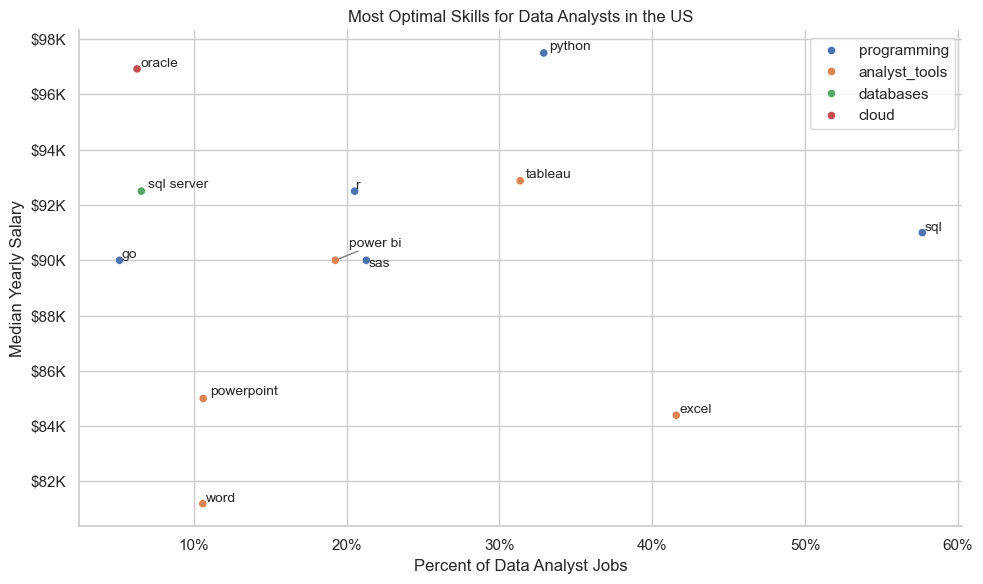

In [1012]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_plot, x='skill_percent', y='median_salary', hue='Technology')
sns.despine()
sns.set_theme(style='ticks')




texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append (plt.text(df_da_skills_high_demand ['skill_percent'].iloc[i], df_da_skills_high_demand ['median_salary'].iloc[i], txt, fontsize=10)
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${(int(y/1000)):}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.legend()
plt.tight_layout()
plt.show()